Total views: 39


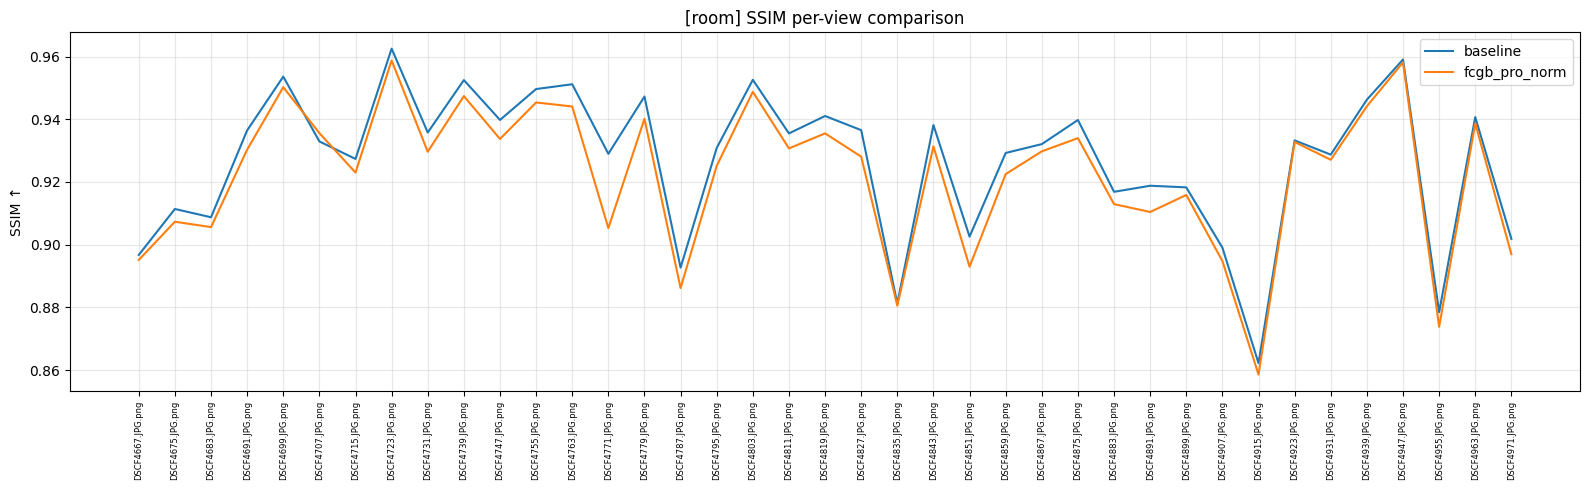

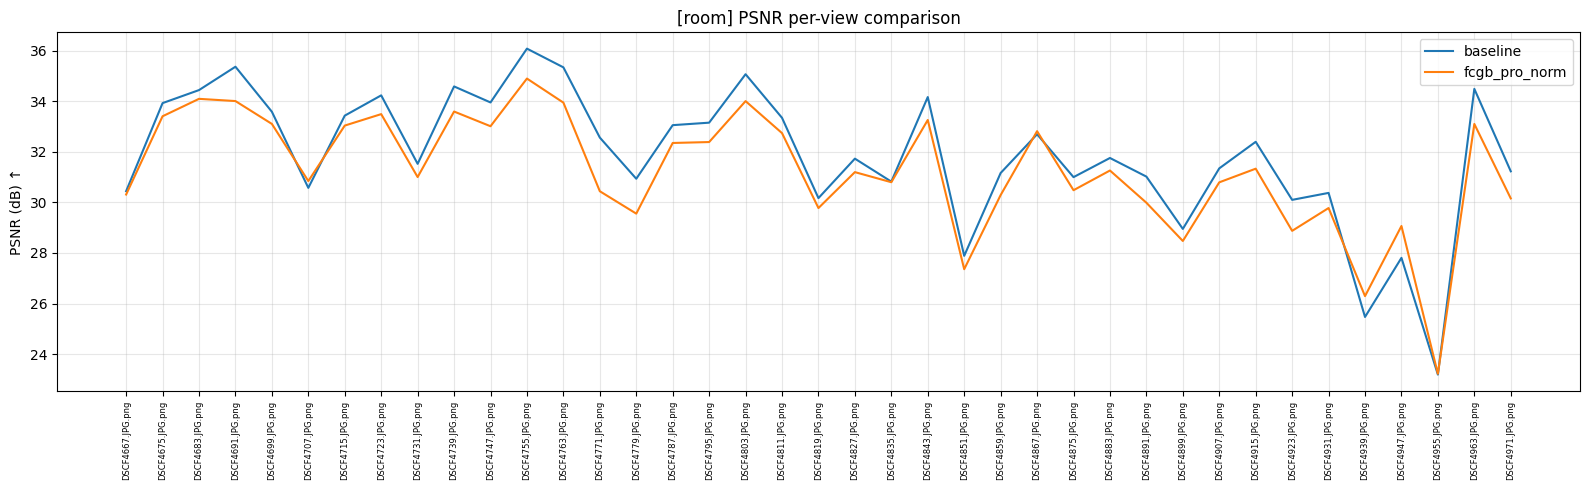

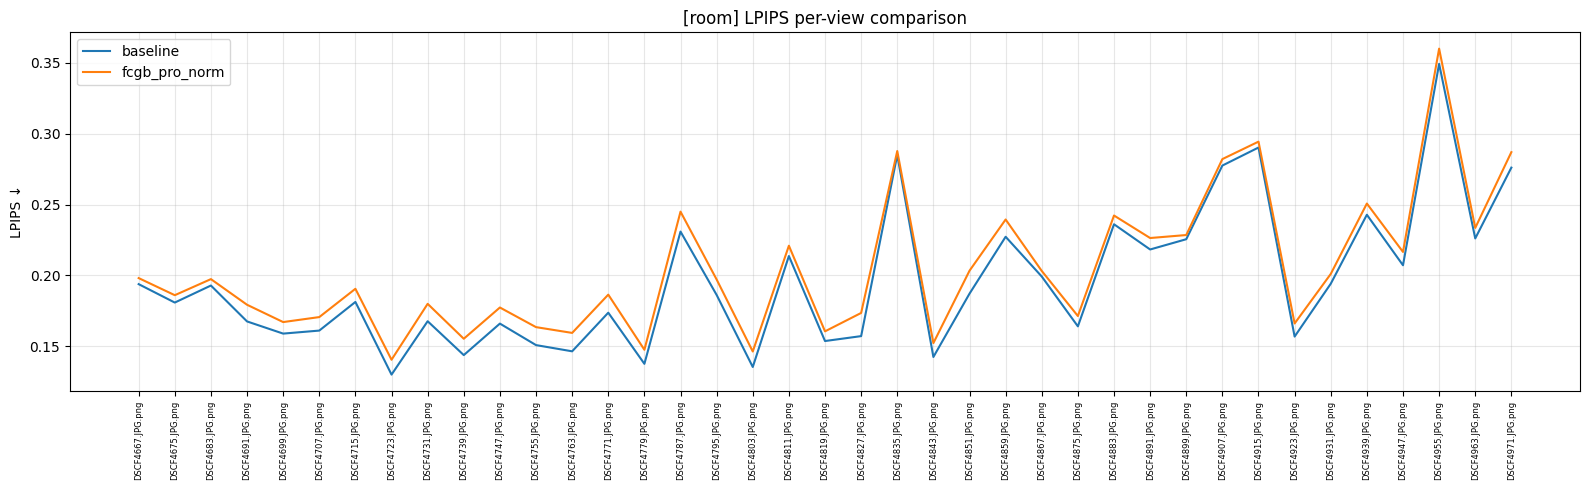

In [7]:
import json
import matplotlib.pyplot as plt
scene_name = "room"

baseline_json = f"/home/jian/gaussian-splatting/output/mip360/{scene_name}/rendered/baseline/per_view.json"
fcgb_json     = f"/home/jian/gaussian-splatting-2/output/mip360/{scene_name}/rendered/fcgb_pro_norm/per_view.json"


def load_metrics(path):
    with open(path, "r") as f:
        data = json.load(f)

    method_key = next(iter(data))  # "ours_30000"
    return data[method_key]


baseline = load_metrics(baseline_json)
fcgb     = load_metrics(fcgb_json)

# 对齐图像名
image_names = sorted(
    set(baseline["SSIM"].keys()) & set(fcgb["SSIM"].keys())
)

print(f"Total views: {len(image_names)}")


def plot_metric(metric, ylabel):
    b_vals = [baseline[metric][k] for k in image_names]
    f_vals = [fcgb[metric][k] for k in image_names]

    plt.figure(figsize=(16, 5))
    plt.plot(image_names, b_vals, label="baseline", linewidth=1.5)
    plt.plot(image_names, f_vals, label="fcgb_pro_norm", linewidth=1.5)

    plt.xticks(rotation=90, fontsize=6)
    plt.ylabel(ylabel)
    plt.title(f"[{scene_name}] {metric} per-view comparison")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_metric("SSIM",  "SSIM ↑")
plot_metric("PSNR",  "PSNR (dB) ↑")
plot_metric("LPIPS", "LPIPS ↓")
